In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("29-country_data.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
import math
def plot_all_histograms(df,title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5*n_cols,4*n_rows))

    for i, col in enumerate (num_cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df[col],bins=30,kde=True)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

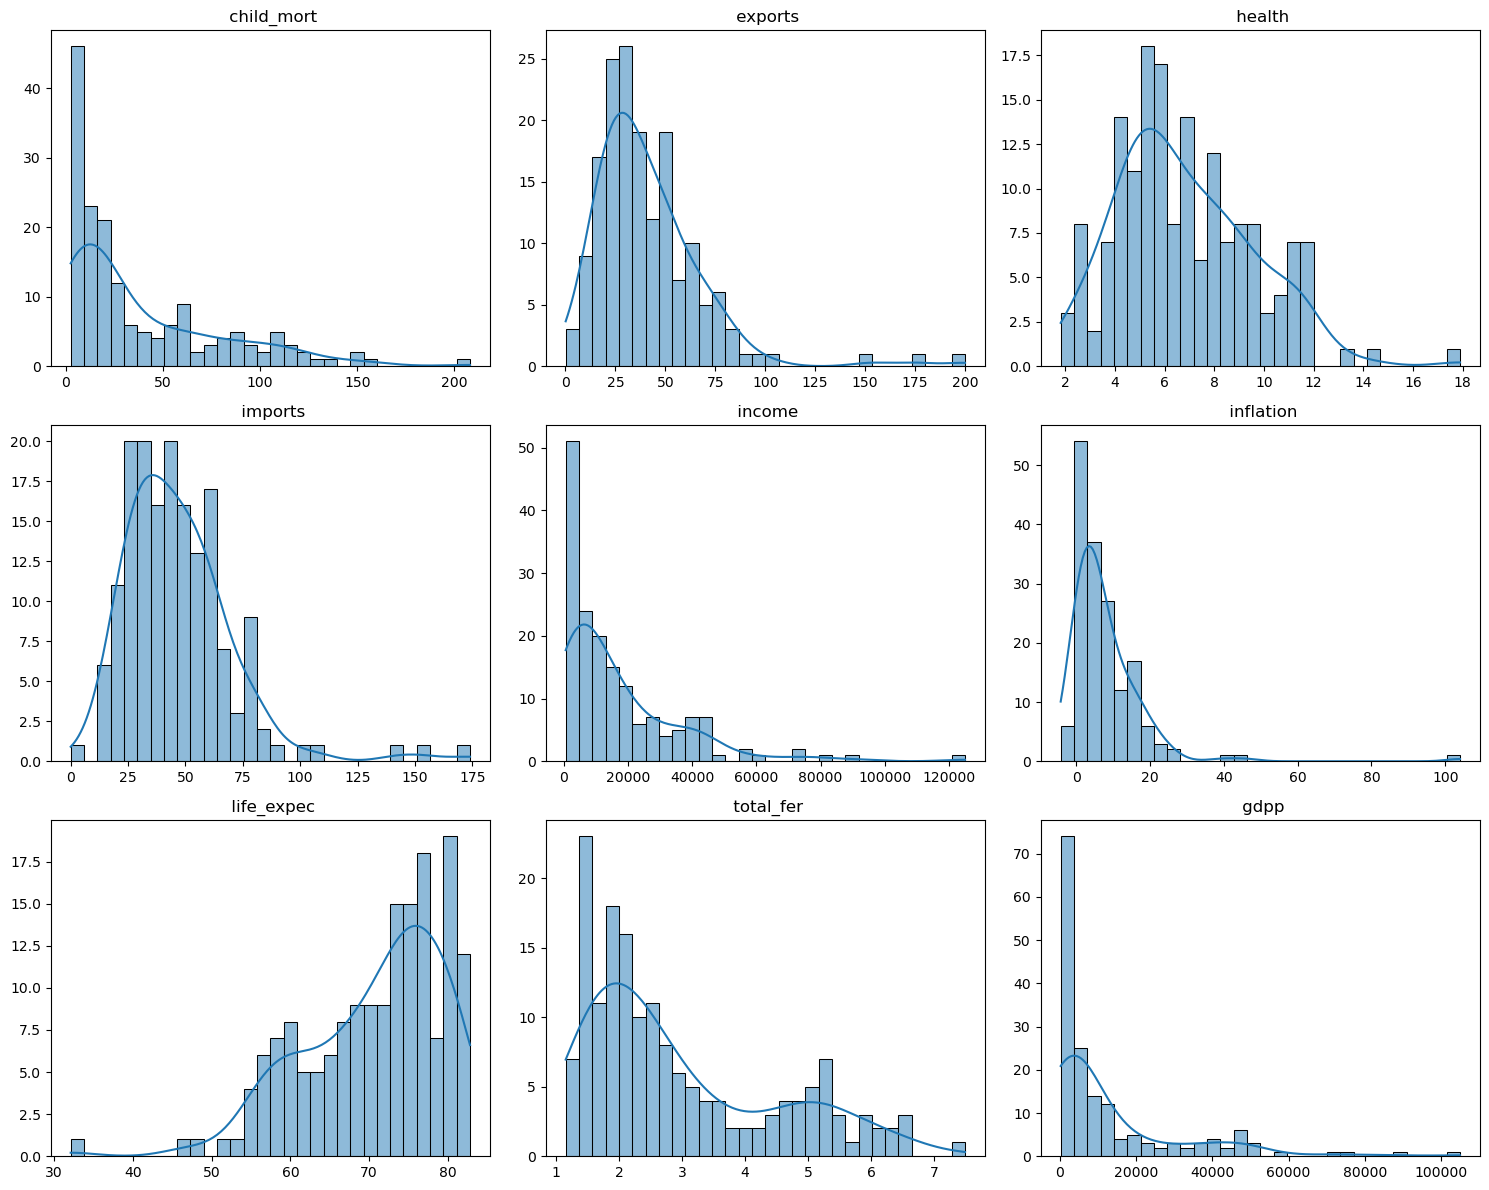

In [7]:
plot_all_histograms(df)

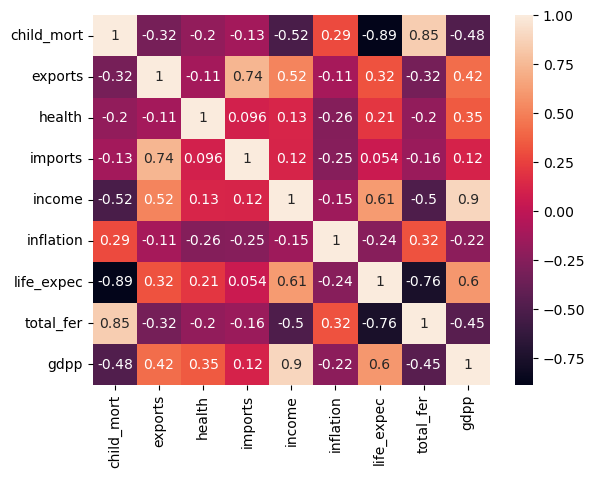

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

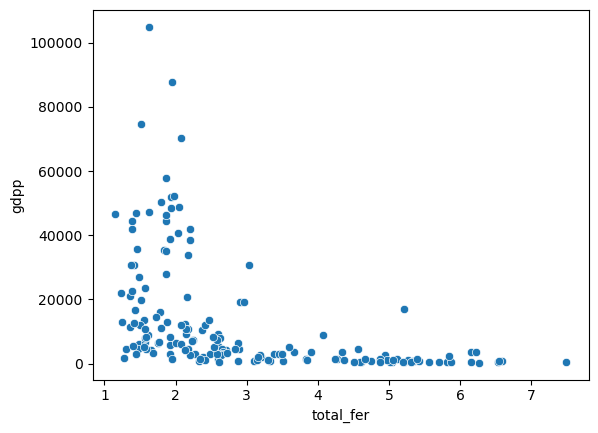

In [9]:
sns.scatterplot(data=df, x="total_fer",y="gdpp")
plt.show()

In [10]:
df2 = df.drop("country",axis=1)

In [11]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler = MinMaxScaler()

In [14]:
df2 = scaler.fit_transform(df2)

In [15]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [16]:
df2 = pd.DataFrame(df2,columns=['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'])

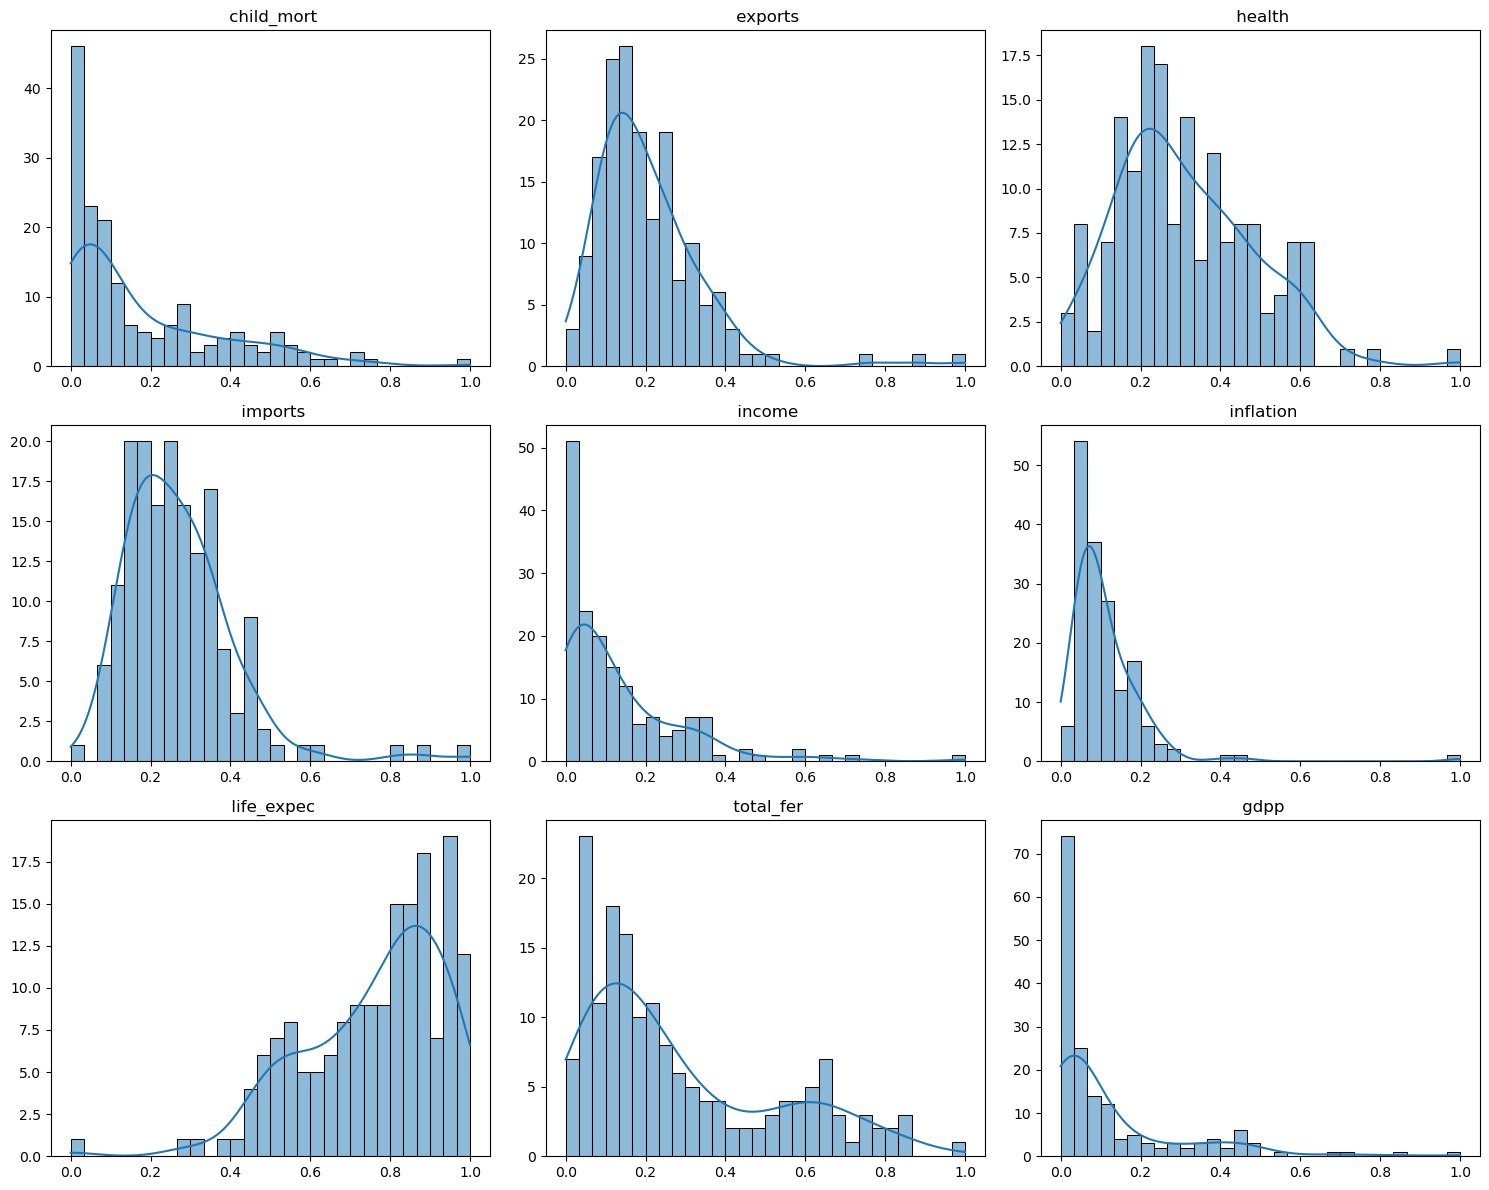

In [17]:
plot_all_histograms(df2)

In [18]:
from sklearn.decomposition import PCA

In [19]:
pca = PCA()

In [20]:
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

In [21]:
pca_df2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [22]:
pca.explained_variance_

array([0.14180615, 0.03450913, 0.03171502, 0.02513534, 0.00974048,
       0.00776992, 0.00306922, 0.00228894, 0.00178941])

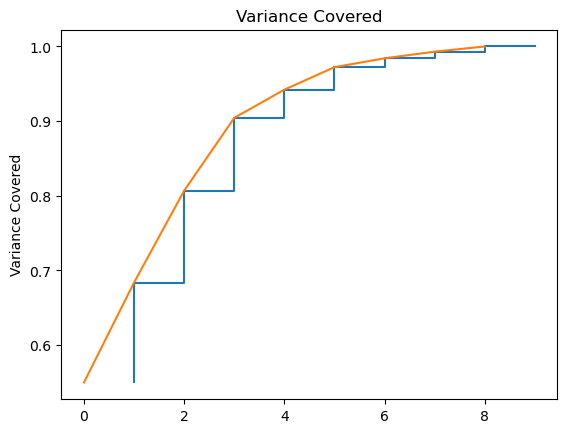

In [23]:
plt.step(list(range(1,10)),np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covered")
plt.title("Variance Covered")
plt.show()

In [24]:
pca_df2 = pca_df2.drop(columns=[3,4,5,6,7,8])

In [25]:
pca_df2

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [27]:
import warnings
warnings.filterwarnings("ignore")

In [28]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(pca_df2)
    wcss.append(kmeans.inertia_)

In [29]:
wcss

[34.53302925308175,
 17.69539536890408,
 11.270622261541492,
 9.907190890199841,
 7.25114670313945,
 7.260179384292687,
 5.208727907815302,
 5.092897825907498,
 4.403213374456491,
 4.077587682381903]

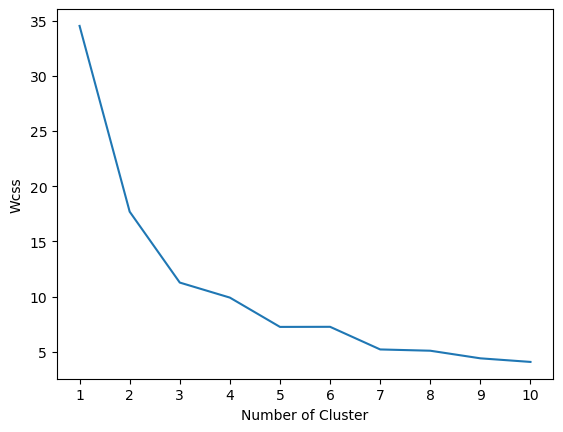

In [30]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Cluster")
plt.ylabel("Wcss")
plt.show()

In [31]:
model = KMeans(n_clusters=3)
model.fit(pca_df2)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [32]:
labels=model.labels_

In [33]:
silhouette_score(pca_df2,labels)

0.43863203452366833

In [34]:
df["Class"] = labels

In [35]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,0


In [36]:
df["Class"].value_counts()

Class
2    86
0    46
1    35
Name: count, dtype: int64

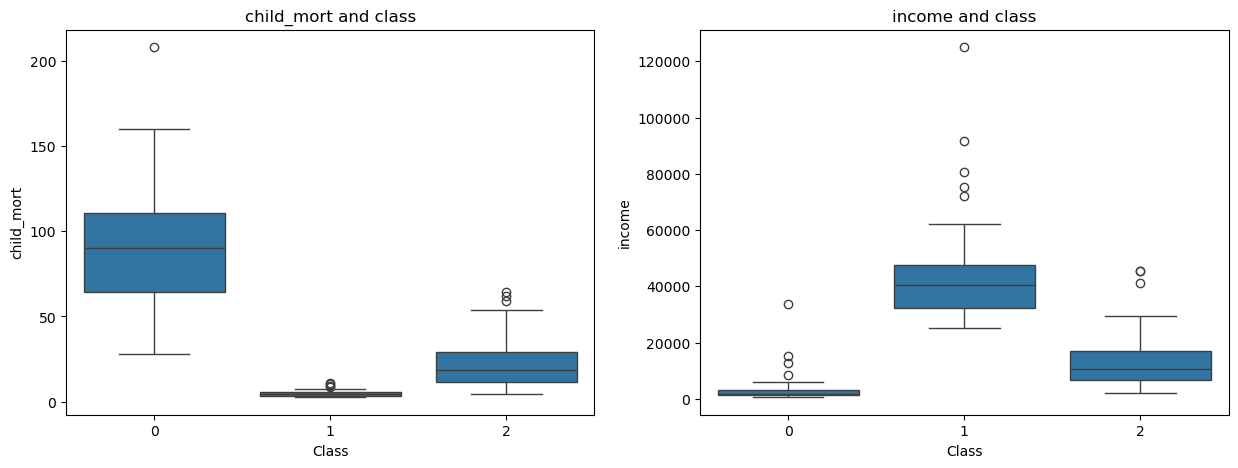

In [37]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, y="child_mort", x="Class")
plt.title("child_mort and class")
plt.subplot(1,2,2)
sns.boxplot(data=df, y="income",x="Class")
plt.title("income and class")
plt.show()

In [38]:
import plotly.express as px

In [39]:
pca_df2.insert(0, column="Country", value=df["country"])

In [40]:
cluster_means = df.groupby("Class")["income"].mean().sort_values()
ordered_labels = cluster_means.index.to_list()
mapping = {
    ordered_labels[0] : "Budget Needed",
    ordered_labels[1] : "In Between",
    ordered_labels[2] : "No Budget Needed"
}
pca_df2["Class"] = df["Class"].map(mapping)

In [41]:
pca_df2

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,In Between
163,Venezuela,-0.061133,-0.171339,-0.058586,In Between
164,Vietnam,-0.115512,-0.032034,-0.195243,In Between
165,Yemen,0.332968,-0.019824,-0.029989,Budget Needed


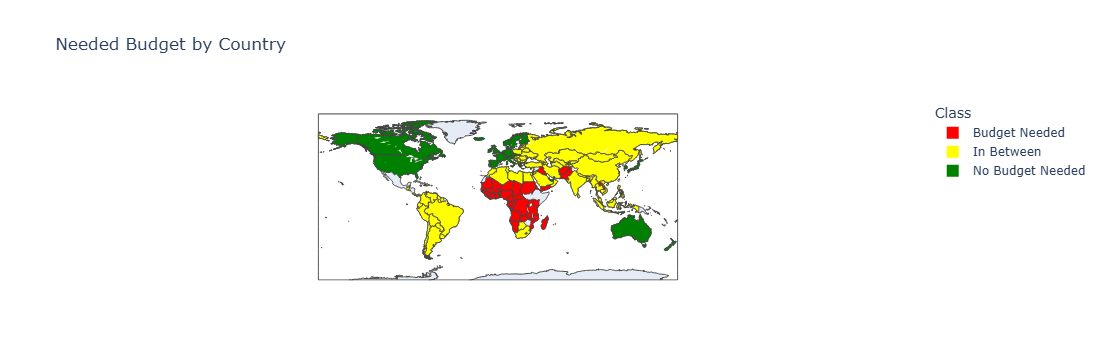

In [42]:
fig = px.choropleth(
    pca_df2[["Country","Class"]],
    locationmode="country names",
    locations="Country",
    title="Needed Budget by Country",
    color = pca_df2["Class"],
    color_discrete_map={
                    "No Budget Needed":"Green",
                    "In Between":"Yellow",
                    "Budget Needed":"Red"
    })
fig.update_geos(fitbounds = "locations", visible=True)
fig.show()    

In [43]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'Class'],
      dtype='object')

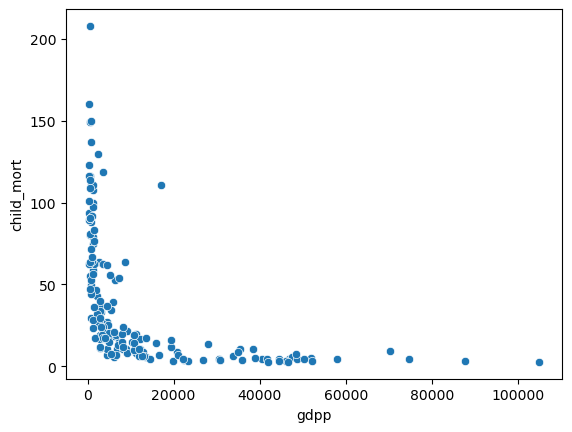

In [44]:
sns.scatterplot(data=df, x="gdpp",y="child_mort")
plt.show()

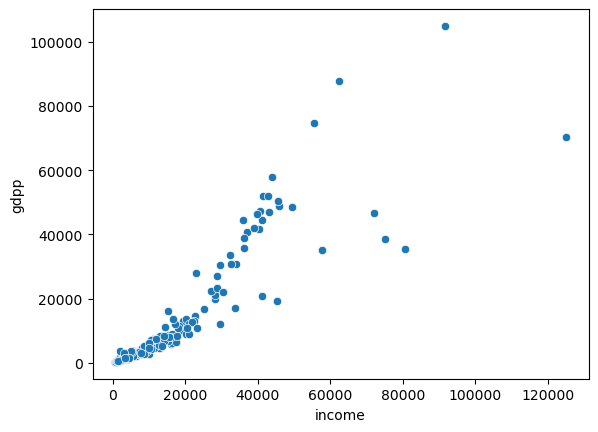

In [45]:
sns.scatterplot(data=df,x="income",y="gdpp")
plt.show()

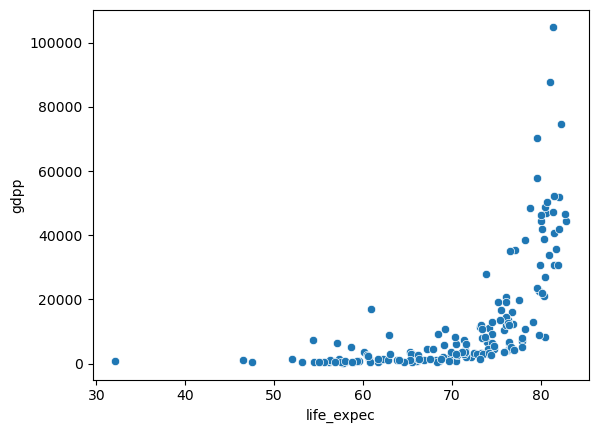

In [46]:
sns.scatterplot(data=df,x="life_expec",y="gdpp")
plt.show()

In [47]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


In [48]:
from sklearn.cluster import DBSCAN, HDBSCAN

In [49]:
dbscan = DBSCAN()

In [50]:
dbscan.fit(df2)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [51]:
dbscan.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [52]:
labels = dbscan.labels_

In [53]:
n_clusters = len(set(labels)) -(1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(n_clusters,n_noise)

1 6


In [54]:
eps_values = [0.1,0.2,0.3,0.4,0.5,0.6,0.8,1.0]
min_sample_values = [1,2,3,4,5,6]

In [55]:
results = []

for eps in eps_values:
    for min_samples in min_sample_values:
        db = DBSCAN(eps = eps, min_samples=min_samples).fit(df2)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhoutte =silhouette_score(df2, labels)
        results.append(
            {
                "eps" : eps,
                "min_sample":min_samples,
                "n_clusters":len(set(labels)) -(1 if -1 in labels else 0),
                "Silhoutte":silhoutte
            }
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhoutte",ascending=False)

In [56]:
results_df

,eps,min_sample,n_clusters,Silhoutte
39,0.8,6,1,0.526549
32,0.6,5,1,0.526549
30,0.6,3,1,0.526549
31,0.6,4,1,0.526549
29,0.6,2,1,0.526549
33,0.6,6,1,0.526549
37,0.8,4,1,0.526549
38,0.8,5,1,0.526549
27,0.5,6,1,0.499396
26,0.5,5,1,0.499396


In [57]:
hdbscan = HDBSCAN()

In [58]:
hdbscan.fit(df2)

,min_cluster_size,5
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [59]:
hdbscan.labels_

array([ 0,  1,  1, -1,  1,  1,  1,  2,  2, -1, -1, -1,  1,  1,  1, -1,  1,
        0,  1,  1,  1, -1,  1, -1,  1,  0, -1,  1,  0,  2,  1, -1, -1,  1,
        1,  1,  0, -1, -1,  1,  0,  1, -1,  1,  2,  1,  1,  1,  1, -1, -1,
        1,  1,  2,  2, -1,  0,  1,  2,  0,  2,  1,  1,  0,  0,  1, -1,  1,
        2,  1,  1,  1, -1, -1, -1,  2,  1,  2, -1,  1,  0, -1, -1,  1, -1,
        1,  1, -1, -1, -1,  1, -1,  1,  0,  0, -1,  1, -1, -1, -1,  1, -1,
       -1, -1,  1,  1,  0, -1, -1,  1, -1,  2, -1, -1, -1, -1, -1, -1,  1,
        1,  1,  1,  2, -1,  1, -1, -1, -1, -1,  0,  1, -1, -1, -1,  1, -1,
       -1, -1,  1,  2, -1,  1,  0,  1,  2, -1, -1,  0,  1, -1,  0, -1,  1,
        1, -1,  0,  1, -1,  2, -1,  1,  1,  1, -1, -1,  0,  0])

In [60]:
hdbscan_labels = hdbscan.labels_

In [61]:
n_clusters = len(set(labels)) -(1 if -1 in labels else 0)
n_noise = list(hdbscan_labels).count(-1)
print(n_clusters,n_noise)

1 65


In [62]:
min_cluster_size = [2,3,4,5,6,7,8,9,10]
min_samples = [None,1,2,3,4,5]

In [63]:
results = []

for min_cluster in min_cluster_size:
    for min_sample in min_samples:
        db = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(df2)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhoutte =silhouette_score(df2, labels)
        results.append(
            {
                "min_cluster_size" : min_cluster,
                "min_samples":min_sample,
                "n_clusters":len(set(labels)) -(1 if -1 in labels else 0),
                "Silhoutte":silhoutte
            }
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhoutte",ascending=False)

In [64]:
results_df

,min_cluster_size,min_samples,n_clusters,Silhoutte
44,9,2.0,3,0.210128
37,8,1.0,3,0.210128
50,10,2.0,3,0.210128
49,10,1.0,3,0.210128
38,8,2.0,3,0.210128
43,9,1.0,3,0.210128
45,9,3.0,3,0.162454
33,7,3.0,3,0.162454
39,8,3.0,3,0.162454
27,6,3.0,3,0.162454


In [65]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [66]:
df = df.drop("country",axis=1)

In [67]:
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [68]:
df[["exports_scaled","imports_scaled"]] = scaler.fit_transform(df[["exports","imports"]])

In [69]:
r_exports = (df["exports"].mean()) / ((df["exports"].mean()) + (df["imports"].mean()))
r_imports = (df["imports"].mean()) / ((df["imports"].mean()) + (df["exports"].mean()))

In [70]:
df["Trade"] = df["exports_scaled"]*r_exports + df["imports_scaled"]*r_imports

In [71]:
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class,exports_scaled,imports_scaled,Trade
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0,0.049482,0.257765,0.160465
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0.139531,0.279037,0.213867
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0.191559,0.180149,0.185480
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0,0.311125,0.246266,0.276565
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0.227079,0.338255,0.286319


In [72]:
df3 = df.drop(columns=["exports","imports","exports_scaled","imports_scaled","Class"],axis=1)

In [73]:
df3.head()

,child_mort,health,income,inflation,life_expec,total_fer,gdpp,Trade
0,90.2,7.58,1610,9.44,56.2,5.82,553,0.160465
1,16.6,6.55,9930,4.49,76.3,1.65,4090,0.213867
2,27.3,4.17,12900,16.10,76.5,2.89,4460,0.185480
3,119.0,2.85,5900,22.40,60.1,6.16,3530,0.276565
4,10.3,6.03,19100,1.44,76.8,2.13,12200,0.286319


In [74]:
df3[["child_mort_scaled","life_expec_scaled","health_scaled","total_fer_scaled","income_scaled","inflation_scaled","gdpp_scaled"]] = scaler.fit_transform(df[["child_mort","life_expec","health","total_fer","income","inflation","gdpp"]])

In [75]:
df3["total_fer_value"] = 1 - df3["total_fer_scaled"]
df3["inflation_value"] = 1 - df3["inflation_scaled"]

In [76]:
df3["Health"] = df3[["child_mort_scaled","life_expec_scaled","health_scaled","total_fer_value"]].mean(axis=1)

In [77]:
df3.head()

,child_mort,health,income,inflation,life_expec,total_fer,gdpp,Trade,child_mort_scaled,life_expec_scaled,health_scaled,total_fer_scaled,income_scaled,inflation_scaled,gdpp_scaled,total_fer_value,inflation_value,Health
0,90.2,7.58,1610,9.44,56.2,5.82,553,0.160465,0.426485,0.475345,0.358608,0.736593,0.008047,0.126144,0.003073,0.263407,0.873856,0.380961
1,16.6,6.55,9930,4.49,76.3,1.65,4090,0.213867,0.068160,0.871795,0.294593,0.078864,0.074933,0.080399,0.036833,0.921136,0.919601,0.538921
2,27.3,4.17,12900,16.10,76.5,2.89,4460,0.185480,0.120253,0.875740,0.146675,0.274448,0.098809,0.187691,0.040365,0.725552,0.812309,0.467055
3,119.0,2.85,5900,22.40,60.1,6.16,3530,0.276565,0.566699,0.552268,0.064636,0.790221,0.042535,0.245911,0.031488,0.209779,0.754089,0.348346
4,10.3,6.03,19100,1.44,76.8,2.13,12200,0.286319,0.037488,0.881657,0.262275,0.154574,0.148652,0.052213,0.114242,0.845426,0.947787,0.506711


In [78]:
df3["Economy"] = df3[["income_scaled","inflation_value","gdpp_scaled"]].mean(axis=1)

In [79]:
df3.head()

,child_mort,health,income,inflation,life_expec,total_fer,gdpp,Trade,child_mort_scaled,life_expec_scaled,health_scaled,total_fer_scaled,income_scaled,inflation_scaled,gdpp_scaled,total_fer_value,inflation_value,Health,Economy
0,90.2,7.58,1610,9.44,56.2,5.82,553,0.160465,0.426485,0.475345,0.358608,0.736593,0.008047,0.126144,0.003073,0.263407,0.873856,0.380961,0.294992
1,16.6,6.55,9930,4.49,76.3,1.65,4090,0.213867,0.068160,0.871795,0.294593,0.078864,0.074933,0.080399,0.036833,0.921136,0.919601,0.538921,0.343789
2,27.3,4.17,12900,16.10,76.5,2.89,4460,0.185480,0.120253,0.875740,0.146675,0.274448,0.098809,0.187691,0.040365,0.725552,0.812309,0.467055,0.317161
3,119.0,2.85,5900,22.40,60.1,6.16,3530,0.276565,0.566699,0.552268,0.064636,0.790221,0.042535,0.245911,0.031488,0.209779,0.754089,0.348346,0.276038
4,10.3,6.03,19100,1.44,76.8,2.13,12200,0.286319,0.037488,0.881657,0.262275,0.154574,0.148652,0.052213,0.114242,0.845426,0.947787,0.506711,0.403560


In [80]:
df3.columns

Index(['child_mort', 'health', 'income', 'inflation', 'life_expec',
       'total_fer', 'gdpp', 'Trade', 'child_mort_scaled', 'life_expec_scaled',
       'health_scaled', 'total_fer_scaled', 'income_scaled',
       'inflation_scaled', 'gdpp_scaled', 'total_fer_value', 'inflation_value',
       'Health', 'Economy'],
      dtype='object')

In [81]:
drop_columns = ['child_mort', 'health', 'income', 'inflation', 'life_expec',
       'total_fer', 'gdpp', 'child_mort_scaled', 'life_expec_scaled',
       'health_scaled', 'total_fer_scaled', 'income_scaled',
       'inflation_scaled', 'gdpp_scaled', 'total_fer_value', 'inflation_value']

In [82]:
df3 = df3.drop(columns=drop_columns,axis=1)

In [83]:
df3.head()

,Trade,Health,Economy
0,0.160465,0.380961,0.294992
1,0.213867,0.538921,0.343789
2,0.185480,0.467055,0.317161
3,0.276565,0.348346,0.276038
4,0.286319,0.506711,0.403560


In [84]:
new_dbscan = DBSCAN()

In [85]:
new_dbscan.fit(df3)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [86]:
new_dbscan.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [87]:
new_dbscan_labels = new_dbscan.labels_

In [88]:
n_clusters = len(set(new_dbscan_labels)) -(1 if -1 in labels else 0)
n_noise = list(new_dbscan_labels).count(-1)
print(n_clusters,n_noise)

0 0


In [89]:
eps_values = [0.1,0.2,0.3,0.4,0.5,0.6,0.8,1.0]
min_sample_values = [1,2,3,4,5,6]

In [90]:
results = []

for eps in eps_values:
    for min_samples in min_sample_values:
        db = DBSCAN(eps = eps, min_samples=min_samples).fit(df3)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhoutte =silhouette_score(df3, labels)
        results.append(
            {
                "eps" : eps,
                "min_sample":min_samples,
                "n_clusters":len(set(labels)) -(1 if -1 in labels else 0),
                "Silhoutte":silhoutte
            }
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhoutte",ascending=False)

In [91]:
results_df

,eps,min_sample,n_clusters,Silhoutte
20,0.4,6,1,0.733110
19,0.4,5,1,0.733110
17,0.3,6,1,0.719296
16,0.3,5,1,0.719296
15,0.3,4,1,0.719296
14,0.3,3,2,0.719296
13,0.3,2,2,0.719296
12,0.3,1,2,0.719296
18,0.4,4,1,0.712324
11,0.2,6,1,0.679515


In [92]:
new_hdbscan = HDBSCAN()

In [93]:
new_hdbscan.fit(df3)

,min_cluster_size,5
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [94]:
new_hdbscan_labels = new_hdbscan.labels_

In [95]:
n_clusters = len(set(new_hdbscan_labels)) -(1 if -1 in labels else 0)
n_noise = list(new_hdbscan_labels).count(-1)
print(n_clusters,n_noise)

3 41


In [96]:
min_cluster_size = [2,3,4,5,6,7,8,9,10]
min_samples = [None,1,2,3,4,5]

In [97]:
results = []

for min_cluster in min_cluster_size:
    for min_sample in min_samples:
        db = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(df3)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhoutte =silhouette_score(df3, labels)
        results.append(
            {
                "min_cluster_size" : min_cluster,
                "min_samples":min_sample,
                "n_clusters":len(set(labels)) -(1 if -1 in labels else 0),
                "Silhoutte":silhoutte
            }
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhoutte",ascending=False)

In [98]:
results_df

,min_cluster_size,min_samples,n_clusters,Silhoutte
7,3,1.0,2,0.719296
8,3,2.0,2,0.719296
26,6,2.0,2,0.314696
43,9,2.0,2,0.314696
25,6,1.0,2,0.314696
37,8,1.0,2,0.314696
20,5,2.0,2,0.314696
19,5,1.0,2,0.314696
38,8,2.0,2,0.314696
32,7,2.0,2,0.314696
